In [1]:
!pip install gymnasium torch numpy matplotlib -q

In [2]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.distributions import Normal
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()

        # Actor outputs raw mean (NO final activation)
        self.actor = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, action_dim)
        )

        # Critic estimates V(s)
        self.critic = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        # Learnable log standard deviation
        self.log_std = nn.Parameter(torch.zeros(action_dim))

    def forward(self, state):
        mean = self.actor(state)
        std = torch.exp(self.log_std).clamp(min=1e-3)
        dist = Normal(mean, std)
        value = self.critic(state)
        return dist, value

# Quick shape check
_test = ActorCritic(3, 1)
_d, _v = _test(torch.randn(1, 3))
print(f"ActorCritic defined — mean shape: {_d.mean.shape}, value shape: {_v.shape}")

ActorCritic defined — mean shape: torch.Size([1, 1]), value shape: torch.Size([1, 1])


In [4]:
class PPO:
    def __init__(self, state_dim, action_dim, action_low, action_high,
                 lr=3e-4, gamma=0.99, lam=0.95, eps_clip=0.2,
                 K_epochs=10, batch_size=64):

        self.model = ActorCritic(state_dim, action_dim).to(device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)

        self.action_low = torch.tensor(action_low, dtype=torch.float32)
        self.action_high = torch.tensor(action_high, dtype=torch.float32)

        self.gamma = gamma
        self.lam = lam
        self.eps_clip = eps_clip
        self.K_epochs = K_epochs
        self.batch_size = batch_size

    def select_action(self, state):
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            dist, value = self.model(state_t)

        raw_action = dist.sample()
        log_prob = dist.log_prob(raw_action).sum(dim=-1)

        # Clamp for the environment, but store raw for log-prob consistency
        env_action = raw_action.clamp(self.action_low, self.action_high)

        return (
            env_action.squeeze(0).cpu().numpy(),
            raw_action.squeeze(0).cpu().numpy(),
            log_prob.squeeze(0).cpu(),
            value.squeeze().cpu().item()
        )

    def compute_gae(self, rewards, values, dones):
        advantages = []
        gae = 0.0
        values = values + [0.0]

        for t in reversed(range(len(rewards))):
            delta = rewards[t] + self.gamma * values[t + 1] * (1 - dones[t]) - values[t]
            gae = delta + self.gamma * self.lam * (1 - dones[t]) * gae
            advantages.insert(0, gae)

        advantages = np.array(advantages, dtype=np.float32)
        returns = advantages + np.array(values[:-1], dtype=np.float32)
        return advantages, returns

    def update(self, states, raw_actions, log_probs_old, rewards, values, dones):
        advantages, returns = self.compute_gae(rewards, values, dones)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        states_t = torch.FloatTensor(np.array(states)).to(device)
        actions_t = torch.FloatTensor(np.array(raw_actions)).to(device)
        log_probs_old_t = torch.stack(log_probs_old).to(device)
        returns_t = torch.FloatTensor(returns).to(device)
        advantages_t = torch.FloatTensor(advantages).to(device)

        n = len(states)
        total_actor_loss = 0
        total_critic_loss = 0
        count = 0

        for _ in range(self.K_epochs):
            idx = np.random.permutation(n)

            for start in range(0, n, self.batch_size):
                batch = idx[start:start + self.batch_size]

                dist, values_new = self.model(states_t[batch])
                log_probs_new = dist.log_prob(actions_t[batch]).sum(dim=-1)
                entropy = dist.entropy().sum(dim=-1).mean()

                ratios = torch.exp(log_probs_new - log_probs_old_t[batch])

                surr1 = ratios * advantages_t[batch]
                surr2 = torch.clamp(ratios, 1 - self.eps_clip, 1 + self.eps_clip) * advantages_t[batch]

                actor_loss = -torch.min(surr1, surr2).mean()
                critic_loss = (returns_t[batch] - values_new.squeeze(-1)).pow(2).mean()

                loss = actor_loss + 0.5 * critic_loss - 0.01 * entropy

                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.model.parameters(), 0.5)
                self.optimizer.step()

                total_actor_loss += actor_loss.item()
                total_critic_loss += critic_loss.item()
                count += 1

        return total_actor_loss / count, total_critic_loss / count

print("PPO Agent defined.")

PPO Agent defined.


In [9]:
env = gym.make("Pendulum-v1")

state_dim  = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
action_low  = float(env.action_space.low[0])
action_high = float(env.action_space.high[0])

print(f"Environment: Pendulum-v1")
print(f"  State dim : {state_dim}")
print(f"  Action dim: {action_dim}  (continuous, range [{action_low}, {action_high}])")

# Recreate agent with better hyperparameters
agent = PPO(state_dim, action_dim, action_low, action_high,
            lr=3e-4,
            gamma=0.99,
            lam=0.95,
            eps_clip=0.2,
            K_epochs=20,       # was 10 — more gradient steps per update
            batch_size=64)

TOTAL_TIMESTEPS = 200_000     # was 300 episodes (~60k steps) — now 200k
UPDATE_EVERY    = 2048        # collect this many steps, then update

buf_states, buf_raw_actions, buf_log_probs = [], [], []
buf_rewards, buf_values, buf_dones = [], [], []

episode_rewards = []
ep_reward   = 0.0
update_num  = 0
ep_count    = 0

state, _ = env.reset()
start_time = time.time()

for t in range(1, TOTAL_TIMESTEPS + 1):

    env_action, raw_action, log_prob, value = agent.select_action(state)
    next_state, reward, terminated, truncated, _ = env.step(env_action)
    done = terminated or truncated

    buf_states.append(state)
    buf_raw_actions.append(raw_action)
    buf_log_probs.append(log_prob)
    buf_rewards.append(reward)
    buf_values.append(value)
    buf_dones.append(float(done))

    state = next_state
    ep_reward += reward

    if done:
        ep_count += 1
        episode_rewards.append(ep_reward)
        ep_reward = 0.0
        state, _ = env.reset()

        if ep_count % 20 == 0:
            avg = np.mean(episode_rewards[-20:])
            elapsed = time.time() - start_time
            print(f"Ep {ep_count:>4d}  |  Timestep: {t:>7d}/{TOTAL_TIMESTEPS}"
                  f"  |  Avg(20): {avg:>8.1f}"
                  f"  |  Updates: {update_num}"
                  f"  |  Time: {elapsed:.0f}s")

    if t % UPDATE_EVERY == 0:
        a_loss, c_loss = agent.update(
            buf_states, buf_raw_actions, buf_log_probs,
            buf_rewards, buf_values, buf_dones
        )
        buf_states, buf_raw_actions, buf_log_probs = [], [], []
        buf_rewards, buf_values, buf_dones = [], [], []
        update_num += 1

env.close()

elapsed = time.time() - start_time
print(f"\n{'='*62}")
print(f"Training complete — {TOTAL_TIMESTEPS:,} timesteps in {elapsed:.1f}s")
print(f"Total episodes     : {ep_count}")
print(f"Total PPO updates  : {update_num}")
print(f"Final Avg (last 20): {np.mean(episode_rewards[-20:]):.1f}")
print(f"Best Episode       : {max(episode_rewards):.1f}")

Environment: Pendulum-v1
  State dim : 3
  Action dim: 1  (continuous, range [-2.0, 2.0])
Ep   20  |  Timestep:    4000/200000  |  Avg(20):  -1286.1  |  Updates: 1  |  Time: 5s
Ep   40  |  Timestep:    8000/200000  |  Avg(20):  -1075.1  |  Updates: 3  |  Time: 13s
Ep   60  |  Timestep:   12000/200000  |  Avg(20):  -1323.8  |  Updates: 5  |  Time: 21s
Ep   80  |  Timestep:   16000/200000  |  Avg(20):  -1194.2  |  Updates: 7  |  Time: 28s
Ep  100  |  Timestep:   20000/200000  |  Avg(20):  -1180.4  |  Updates: 9  |  Time: 36s
Ep  120  |  Timestep:   24000/200000  |  Avg(20):  -1200.2  |  Updates: 11  |  Time: 43s
Ep  140  |  Timestep:   28000/200000  |  Avg(20):  -1245.2  |  Updates: 13  |  Time: 51s
Ep  160  |  Timestep:   32000/200000  |  Avg(20):  -1131.7  |  Updates: 15  |  Time: 59s
Ep  180  |  Timestep:   36000/200000  |  Avg(20):  -1189.2  |  Updates: 17  |  Time: 66s
Ep  200  |  Timestep:   40000/200000  |  Avg(20):  -1150.1  |  Updates: 19  |  Time: 75s
Ep  220  |  Timestep:   44

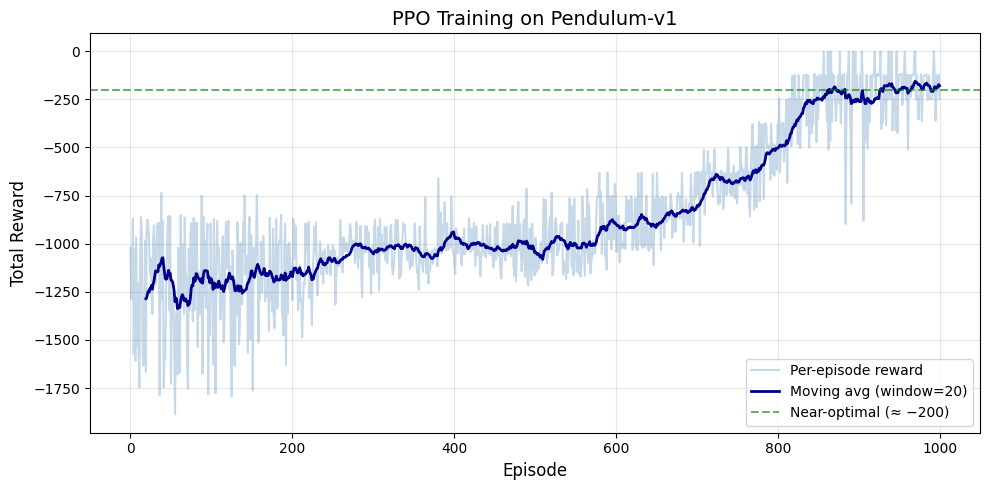

In [10]:
def smooth(data, window=20):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(episode_rewards, alpha=0.3, color='steelblue', label='Per-episode reward')
smoothed = smooth(episode_rewards, window=20)
ax.plot(range(19, 19 + len(smoothed)), smoothed, color='darkblue', linewidth=2,
        label='Moving avg (window=20)')

ax.axhline(y=-200, color='green', linestyle='--', alpha=0.6, label='Near-optimal (≈ −200)')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Total Reward', fontsize=12)
ax.set_title('PPO Training on Pendulum-v1', fontsize=14)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
def evaluate(agent, env_name="Pendulum-v1", n_episodes=10):
    env = gym.make(env_name)
    eval_rewards = []

    for ep in range(n_episodes):
        state, _ = env.reset()
        total_reward = 0.0

        while True:
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            with torch.no_grad():
                dist, _ = agent.model(state_t)
                action = dist.mean.clamp(agent.action_low, agent.action_high)

            state, reward, terminated, truncated, _ = env.step(action.squeeze(0).cpu().numpy())
            total_reward += reward

            if terminated or truncated:
                break

        eval_rewards.append(total_reward)
        print(f"  Eval Episode {ep+1:>2d}: Reward = {total_reward:.1f}")

    env.close()
    return eval_rewards

print("Evaluating trained agent (deterministic, 10 episodes):")
print("-" * 50)
eval_rewards = evaluate(agent)
print("-" * 50)
print(f"Mean Eval Reward : {np.mean(eval_rewards):.1f} ± {np.std(eval_rewards):.1f}")
print(f"Best Eval Reward : {max(eval_rewards):.1f}")
print(f"Worst Eval Reward: {min(eval_rewards):.1f}")

Evaluating trained agent (deterministic, 10 episodes):
--------------------------------------------------
  Eval Episode  1: Reward = -125.8
  Eval Episode  2: Reward = -240.3
  Eval Episode  3: Reward = -363.8
  Eval Episode  4: Reward = -301.1
  Eval Episode  5: Reward = -1.5
  Eval Episode  6: Reward = -128.3
  Eval Episode  7: Reward = -126.6
  Eval Episode  8: Reward = -454.3
  Eval Episode  9: Reward = -2.5
  Eval Episode 10: Reward = -352.6
--------------------------------------------------
Mean Eval Reward : -209.7 ± 148.4
Best Eval Reward : -1.5
Worst Eval Reward: -454.3


In [12]:
print("=" * 60)
print("        BENCHMARK SUMMARY — PPO on Pendulum-v1")
print("=" * 60)
print(f"  Algorithm          : PPO-Clip + GAE")
print(f"  Environment        : Pendulum-v1 (continuous)")
print(f"  State dim          : {state_dim}")
print(f"  Action dim         : {action_dim} (range [{action_low}, {action_high}])")
print(f"  Training episodes  : {NUM_EPISODES}")
print(f"  Training time      : {elapsed:.1f}s")
print(f"  Device             : {device}")
print(f"  " + "-" * 56)
print(f"  Train Avg (last 20)     : {np.mean(episode_rewards[-20:]):>8.1f}")
print(f"  Train Best episode      : {max(episode_rewards):>8.1f}")
print(f"  Eval Mean  (10 eps)     : {np.mean(eval_rewards):>8.1f}")
print(f"  Eval Std                : {np.std(eval_rewards):>8.1f}")
print(f"  " + "-" * 56)
print(f"  Near-optimal threshold  :   -200.0")
reached = np.mean(eval_rewards) > -400
print(f"  Converged (eval > -400) : {'Yes' if reached else 'Needs more training'}")
print("=" * 60)

        BENCHMARK SUMMARY — PPO on Pendulum-v1
  Algorithm          : PPO-Clip + GAE
  Environment        : Pendulum-v1 (continuous)
  State dim          : 3
  Action dim         : 1 (range [-2.0, 2.0])
  Training episodes  : 300
  Training time      : 386.4s
  Device             : cpu
  --------------------------------------------------------
  Train Avg (last 20)     :   -180.1
  Train Best episode      :     -2.2
  Eval Mean  (10 eps)     :   -209.7
  Eval Std                :    148.4
  --------------------------------------------------------
  Near-optimal threshold  :   -200.0
  Converged (eval > -400) : Yes
